# PART 6

Haikal Ali_1103223071_TK46GAB

# Advanced Logistic Regression and Extensions

Notebook ini dibuat dari materi **Advanced Logistic Regression and Extensions**. Materi ini membahas logistic regression untuk klasifikasi biner, multiclass classification, regularization, multilabel classification, serta metrik evaluasi model.

## Technical requirements

Materi menyarankan penggunaan environment Python yang terpisah. Kebutuhan teknis yang disebutkan adalah:

- Git >= 2.46.x
- Python >= 3.9.x
- Repository GitHub yang sudah di-clone dan environment Python dari `requirements.txt`

## Overview of logistic regression

Logistic regression digunakan untuk masalah klasifikasi, terutama klasifikasi biner. Berbeda dari linear regression yang memprediksi nilai kontinu, logistic regression memprediksi probabilitas suatu data masuk ke kelas tertentu. Nilai probabilitas ini dihasilkan menggunakan fungsi logistic atau sigmoid, sehingga output berada pada rentang 0 sampai 1.

### Getting ready

Contoh pada materi menggunakan dataset **Breast Cancer** dari scikit-learn. Dataset ini digunakan untuk menunjukkan implementasi dasar logistic regression.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  accuracy_score, confusion_matrix,
  classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

In [3]:
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
  df[data.feature_names], df['target'],
  test_size=0.2, random_state=2024
)

### How to do it

Model logistic regression dibuat, dilatih dengan data training, lalu digunakan untuk memprediksi data testing. Evaluasi dilakukan menggunakan accuracy, confusion matrix, dan classification report.

In [5]:
model = LogisticRegression(max_iter=10000)

In [6]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [7]:
y_pred = model.predict(X_test)

In [8]:
accuracy = accuracy_score(y_test, y_pred)

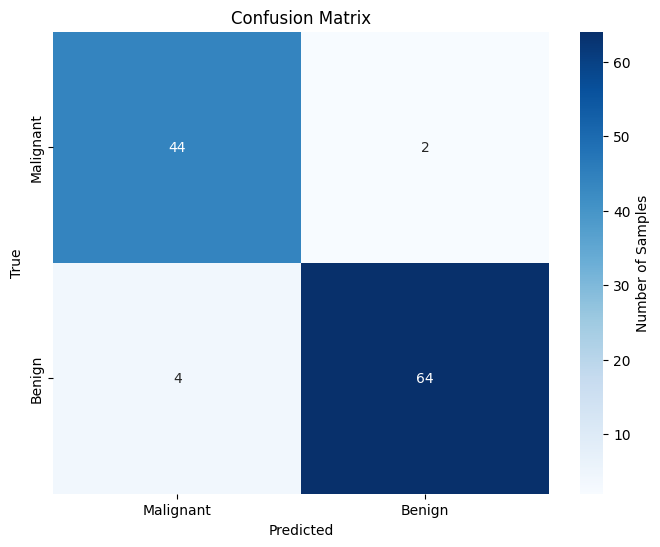

In [9]:
class_names = ['Malignant', 'Benign']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
  cm, annot=True, fmt='d', cmap='Blues',
  xticklabels=class_names,
  yticklabels=class_names,
  cbar_kws={'label': 'Number of Samples'}
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [10]:
report_dict = classification_report(
  y_test, y_pred,
  target_names=class_names,
  output_dict=True
)

In [11]:
report_df = pd.DataFrame(report_dict).transpose()

In [13]:
styled_df = (report_df
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)

print(f'Accuracy: {accuracy:.2f}')
print("Classification Report:")
display(styled_df)

Accuracy: 0.95
Classification Report:


,precision,recall,f1-score,support
Malignant,0.917,0.957,0.936,46
Benign,0.970,0.941,0.955,68
accuracy,0.947,0.947,0.947,1
macro avg,0.943,0.949,0.946,114
weighted avg,0.948,0.947,0.948,114


### How it works

Logistic regression menghitung kombinasi linear dari fitur, lalu mengubahnya dengan fungsi logistic. Hasil akhirnya dapat ditafsirkan sebagai probabilitas suatu data masuk ke kelas positif. Pada logistic regression, konsep **log-odds** digunakan untuk mengubah probabilitas yang terbatas pada 0 sampai 1 menjadi skala linear yang tidak terbatas.

### Evaluating model performance

Evaluasi logistic regression dapat dilakukan dengan beberapa metrik. Accuracy menunjukkan proporsi prediksi yang benar. Confusion matrix menunjukkan detail true positive, true negative, false positive, dan false negative. Precision dan recall membantu melihat performa model dalam mengidentifikasi kasus positif. ROC curve juga dapat digunakan untuk melihat performa model pada berbagai threshold.

### Hands-on exercises

Bagian ini hanya berupa arahan latihan. Intinya adalah menggunakan dataset Breast Cancer, membagi data, melatih `LogisticRegression()`, membuat prediksi, menghitung accuracy, confusion matrix, precision, recall, dan F1-score, lalu membuat visualisasi seperti ROC curve jika diperlukan.

## Multiclass classification techniques

Logistic regression juga dapat digunakan untuk masalah multiclass, yaitu ketika kelas target lebih dari dua. Materi membahas dua strategi: **One-vs-Rest (OvR)** dan **multinomial logistic regression**.

### Getting ready

Contoh pada bagian ini menggunakan dataset **Iris** dari scikit-learn karena dataset ini memiliki tiga kelas.

In [14]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  accuracy_score, classification_report
)
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### How to do it

Model pertama menggunakan pendekatan OvR. Model kedua menggunakan pendekatan multinomial. Keduanya dilatih pada dataset yang sama, lalu dibandingkan melalui classification report.

In [17]:
ovr_model = LogisticRegression(solver='liblinear')
ovr_model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [18]:
multinomial_model = LogisticRegression(
  multi_class='multinomial',
  solver='lbfgs', max_iter=1000
)
multinomial_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [19]:
y_pred_ovr = ovr_model.predict(X_test)

In [20]:
y_pred_multinomial = multinomial_model.predict(X_test)

In [21]:
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
report_ovr = pd.DataFrame(classification_report(
  y_test, y_pred_ovr, output_dict=True
)).transpose()

print("One-vs-Rest (OvR) Logistic Regression:")
styled_ovr = (report_ovr
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)
display(styled_ovr)

One-vs-Rest (OvR) Logistic Regression:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.917,0.917,0.917,12
2,0.933,0.933,0.933,15
accuracy,0.956,0.956,0.956,1
macro avg,0.950,0.950,0.950,45
weighted avg,0.956,0.956,0.956,45


In [22]:
accuracy_multinomial = accuracy_score(
  y_test, y_pred_multinomial
)
report_multinomial = pd.DataFrame(classification_report(
  y_test, y_pred_multinomial,
  output_dict=True
)).transpose()

print("Multinomial Logistic Regression:")
styled_multinomial = (report_multinomial
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)
display(styled_multinomial)

Multinomial Logistic Regression:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.846,0.917,0.880,12
2,0.929,0.867,0.897,15
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.928,0.926,45
weighted avg,0.935,0.933,0.934,45


### How it works

Pada OvR, model membuat satu classifier biner untuk setiap kelas. Kelas yang sedang diprediksi dianggap sebagai kelas positif, sedangkan kelas lainnya dianggap negatif. Pada multinomial logistic regression, model menghitung probabilitas untuk setiap kelas secara langsung menggunakan pendekatan SoftMax. Pendekatan multinomial lebih sesuai ketika kelas bersifat saling eksklusif.

### Key considerations

Pemilihan solver penting karena tidak semua solver cocok untuk semua bentuk logistic regression. `liblinear` umum digunakan untuk OvR, sedangkan `lbfgs` atau `newton-cg` umum digunakan untuk multinomial. Regularization juga berguna untuk mengurangi overfitting. Scaling fitur numerik dapat membantu performa logistic regression.

### There's more

Materi juga menggunakan pairplot dari seaborn untuk melihat hubungan antar fitur pada dataset Iris.

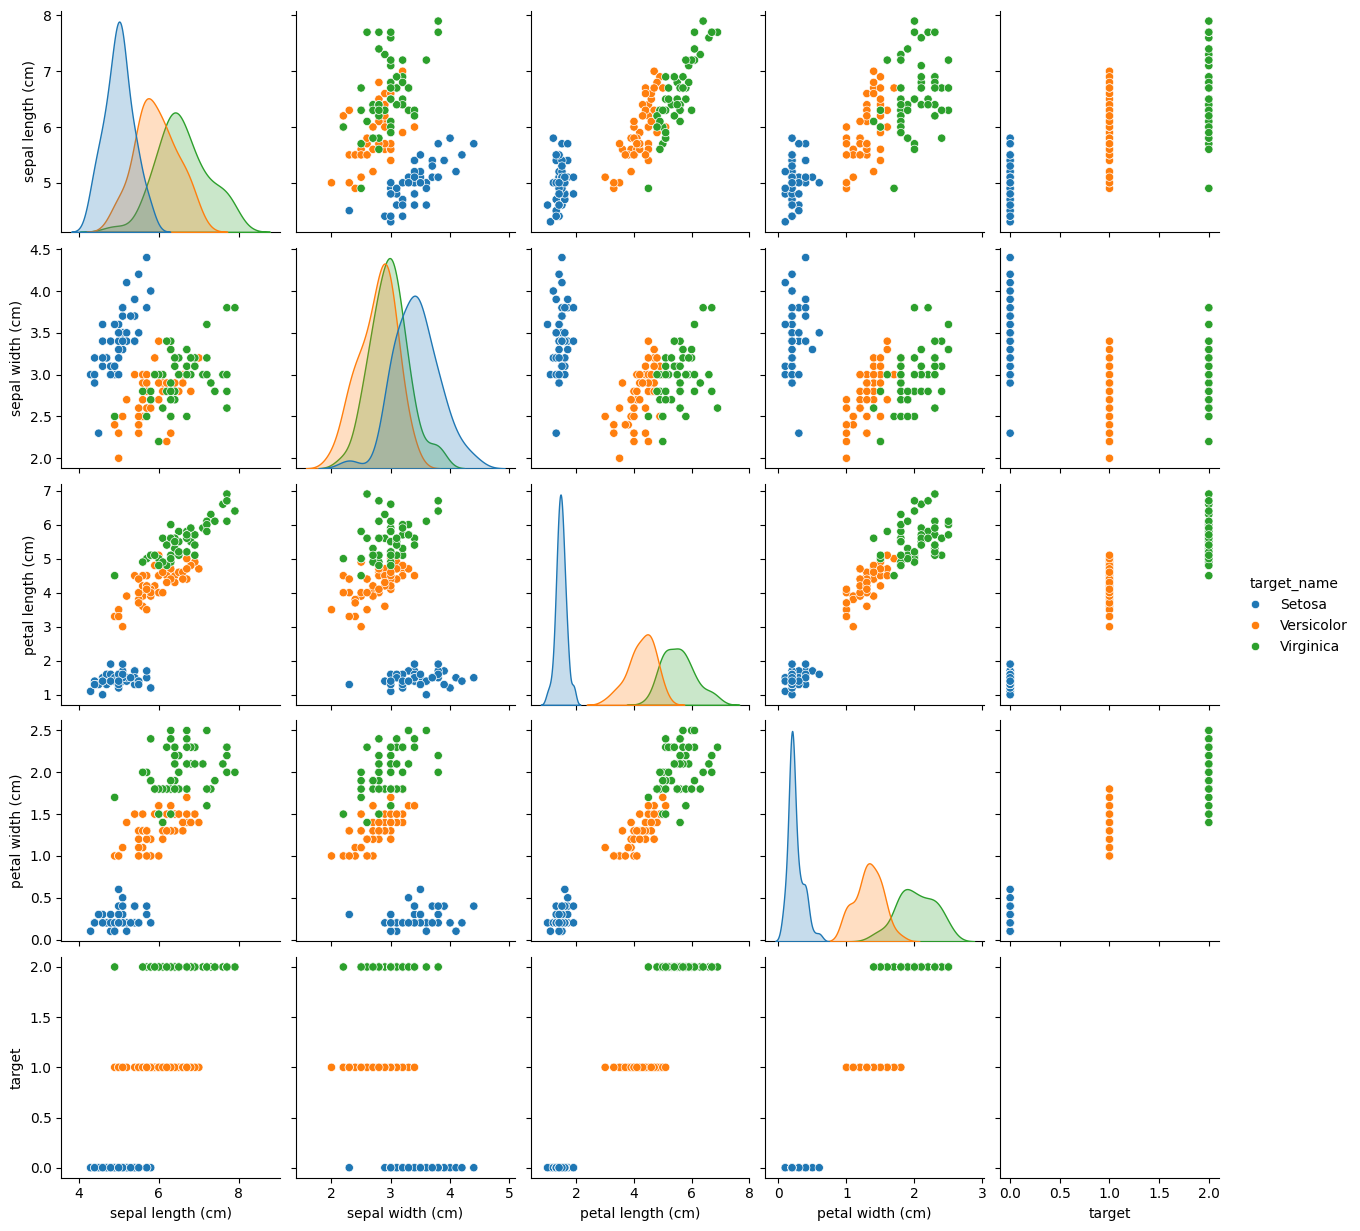

In [23]:
target_names = {
  0: 'Setosa',
  1: 'Versicolor',
  2: 'Virginica'
}

df['target_name'] = df['target'].map(target_names)
sns.pairplot(df, hue='target_name', diag_kind='kde')
plt.show()

### Hands-on exercises

Bagian ini hanya berupa arahan latihan. Latihan yang diminta adalah menggunakan dataset Iris, menerapkan OvR logistic regression dan multinomial logistic regression, membandingkan hasilnya, lalu membuat visualisasi seperti pairplot dan decision boundary.

## Regularization in logistic regression

Regularization digunakan untuk mengurangi overfitting. Pada bagian ini, regularization L2 atau Ridge dan L1 atau Lasso diterapkan pada logistic regression menggunakan dataset Breast Cancer.

### Getting ready

Data dibagi menjadi training dan testing, lalu fitur diskalakan menggunakan `StandardScaler()` sebelum model regularized logistic regression diterapkan.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  accuracy_score, classification_report
)
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [25]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### How to do it

Model Ridge menggunakan `penalty='l2'`, sedangkan model Lasso menggunakan `penalty='l1'`. Keduanya memakai solver `liblinear`.

In [27]:
ridge_model = LogisticRegression(
  penalty='l2', solver='liblinear', C=0.1
)
ridge_model.fit(X_train, y_train)

LogisticRegression(C=0.1, solver='liblinear')

In [28]:
lasso_model = LogisticRegression(
  penalty='l1', solver='liblinear', C=0.1
)
lasso_model.fit(X_train, y_train)

LogisticRegression(C=0.1, penalty='l1', solver='liblinear')

In [29]:
y_pred_ridge = ridge_model.predict(X_test)

In [30]:
y_pred_lasso = lasso_model.predict(X_test)

In [31]:
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
report_ridge = pd.DataFrame(classification_report(
  y_test, y_pred_ridge, output_dict=True
)).transpose()

print("Ridge (L2) Regularized Logistic Regression:")
styled_ridge = (report_ridge
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)
display(styled_ridge)

Ridge (L2) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.985,0.970,0.977,67
1,0.981,0.990,0.986,104
accuracy,0.982,0.982,0.982,1
macro avg,0.983,0.980,0.982,171
weighted avg,0.982,0.982,0.982,171


In [32]:
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
report_lasso = pd.DataFrame(classification_report(
  y_test, y_pred_lasso, output_dict=True
)).transpose()

print("Lasso (L1) Regularized Logistic Regression:")
styled_lasso = (report_lasso
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)
display(styled_lasso)

Lasso (L1) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.930,0.985,0.957,67
1,0.990,0.952,0.971,104
accuracy,0.965,0.965,0.965,1
macro avg,0.960,0.968,0.964,171
weighted avg,0.966,0.965,0.965,171


### How it works

Regularization menambahkan penalti pada loss function agar model tidak memberikan koefisien yang terlalu besar. Ridge atau L2 mengecilkan koefisien mendekati nol, tetapi jarang membuatnya benar-benar nol. Lasso atau L1 dapat membuat sebagian koefisien menjadi nol sehingga dapat berperan sebagai feature selection. Parameter `C` pada `LogisticRegression()` adalah kebalikan dari kekuatan regularization; semakin kecil nilai `C`, semakin kuat regularization.

### Key considerations

Solver harus dipilih sesuai penalty yang digunakan. `liblinear` cocok untuk L1 dan L2 pada dataset kecil. Untuk dataset yang lebih besar, `saga` sering menjadi pilihan. Scaling penting karena regularization sensitif terhadap skala fitur. Nilai `C` perlu dicari agar bias dan variance seimbang.

### There's more

Materi menampilkan perubahan nilai koefisien ketika nilai `C` diubah. Visualisasi ini membantu melihat dampak regularization terhadap fitur.

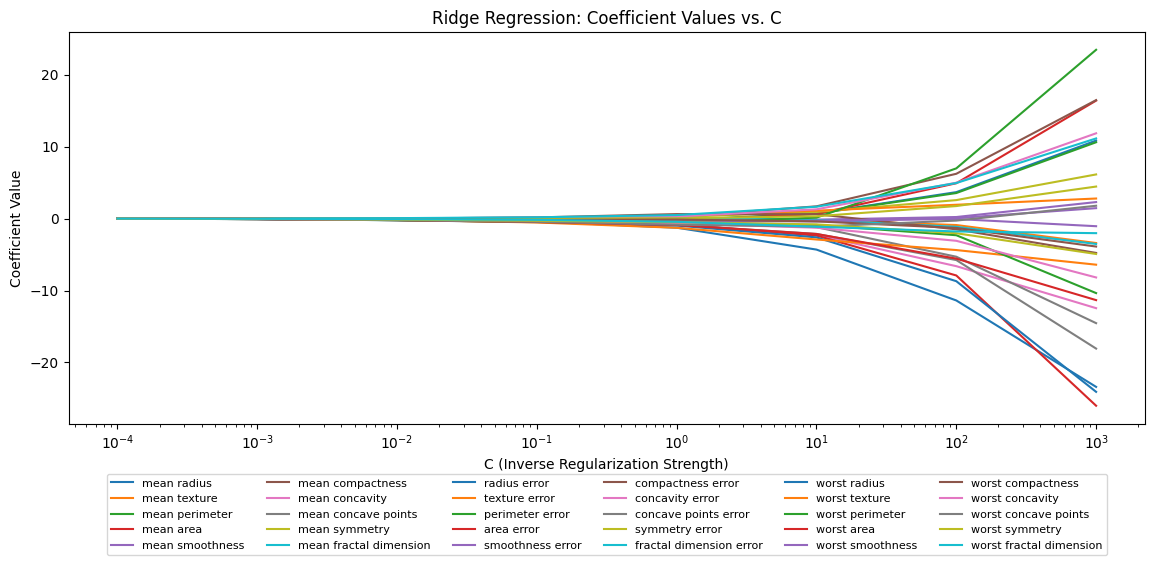

In [33]:
C_values = np.array(
  [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
)
coefs_ridge = []

for C in C_values:
  ridge_model = LogisticRegression(
    penalty='l2', solver='liblinear', C=C
  )
  ridge_model.fit(X_train, y_train)
  coefs_ridge.append(ridge_model.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
  plt.plot(
    C_values, [coef[i] for coef in coefs_ridge],
    label=feature_names[i]
  )

plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Values vs. C')
plt.legend(
  bbox_to_anchor=(0.5, -0.35),
  ncol=6, loc='lower center', fontsize=8
)
plt.tight_layout()
plt.show()

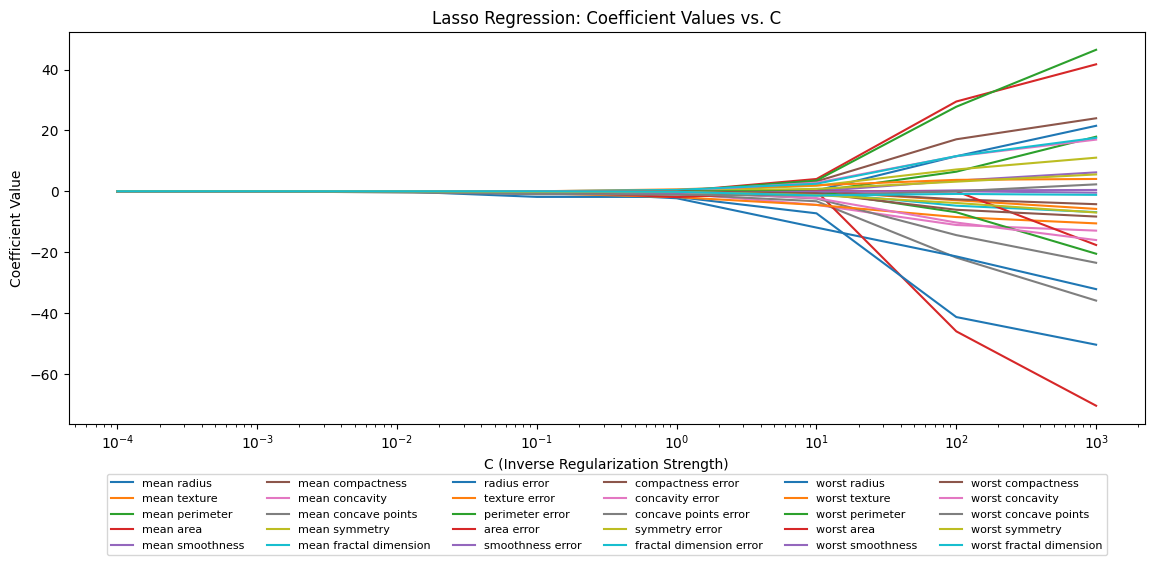

In [34]:
C_values = np.array(
  [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
)
coefs_lasso = []

for C in C_values:
  lasso_model = LogisticRegression(
    penalty='l1', solver='liblinear', C=C
  )
  lasso_model.fit(X_train, y_train)
  coefs_lasso.append(lasso_model.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
  plt.plot(
    C_values, [coef[i] for coef in coefs_lasso],
    label=feature_names[i]
  )

plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficient Values vs. C')
plt.legend(
  bbox_to_anchor=(0.5, -0.35), ncol=6,
  loc='lower center', fontsize=8
)
plt.tight_layout()
plt.show()

### Hands-on exercises

Bagian ini hanya berupa arahan latihan. Latihan yang diminta adalah menggunakan dataset Breast Cancer, melakukan scaling, menerapkan logistic regression dengan L1 dan L2, mengevaluasi hasilnya, lalu membuat plot hubungan antara `C` dan nilai koefisien.

## Multilabel classification concepts

Multilabel classification adalah masalah klasifikasi ketika satu instance dapat memiliki lebih dari satu label sekaligus. Contohnya dapat muncul pada text categorization, image tagging, atau bioinformatics.

### Getting ready

Contoh pada materi membuat dataset sintetis menggunakan `make_multilabel_classification()`.

In [35]:
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  accuracy_score, classification_report, confusion_matrix
)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
X, y = make_multilabel_classification(
  n_samples=1000, n_features=20,
  n_classes=5, n_labels=2, random_state=2024
)

df = pd.DataFrame(
  X,
  columns=[f'feature_{i}' for i in range(X.shape[1])]
)
df['target'] = list(y)

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### How to do it

Karena setiap data dapat memiliki beberapa label, materi melatih satu model logistic regression untuk setiap label.

In [38]:
models = []
y_pred_all = []

In [39]:
for i in range(y_train.shape[1]):
  model = LogisticRegression(solver='liblinear')
  model.fit(X_train, y_train[:, i])
  models.append(model)

  y_pred_label = model.predict(X_test)
  y_pred_all.append(y_pred_label)

In [40]:
y_pred = np.array(y_pred_all).T

In [41]:
accuracy = accuracy_score(y_test, y_pred)
report = pd.DataFrame(classification_report(
  y_test, y_pred, zero_division=1,
  output_dict=True
)).transpose()

print("Classification Report:")
styled_report = (report
  .style
  .background_gradient(
    cmap='Blues',
    subset=['precision', 'recall', 'f1-score']
  )
  .format({
    'precision': '{:.3f}',
    'recall': '{:.3f}',
    'f1-score': '{:.3f}',
    'support': '{:.0f}'
  })
)
display(styled_report)

Classification Report:


,precision,recall,f1-score,support
0,0.808,0.813,0.811,166
1,0.801,0.845,0.823,181
2,0.674,0.333,0.446,93
3,0.750,0.176,0.286,34
4,0.575,0.477,0.522,88
micro avg,0.757,0.653,0.701,562
macro avg,0.722,0.529,0.577,562
weighted avg,0.744,0.653,0.677,562
samples avg,0.787,0.782,0.680,562


### How it works

Multilabel classification memprediksi beberapa label biner untuk setiap instance. Pada contoh ini, strategi yang digunakan mirip OvR, yaitu membuat classifier terpisah untuk setiap label. `make_multilabel_classification()` digunakan untuk membuat data sintetis yang cocok untuk masalah multilabel.

### MultiOutputClassifier()

Materi menyebutkan bahwa scikit-learn menyediakan `MultiOutputClassifier()` sebagai shortcut untuk masalah multilabel. Class ini menerima classifier seperti `LogisticRegression()` dan menerapkannya ke setiap target.

### Visualizing results

Materi membuat co-occurrence matrix untuk melihat label mana yang sering muncul bersamaan.

In [44]:
def plot_label_cooccurrence(
  y, title="Label Co-occurrence Analysis"
):
  cooccurrence = y.T @ y

  diag = np.diag(cooccurrence)
  relative_cooccurrence = cooccurrence / diag[:, None]

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

  sns.heatmap(
    cooccurrence, annot=True, fmt='d',
    cmap='Blues', ax=ax1, annot_kws={"fontsize": 15}
  )
  ax1.set_title('Raw Co-occurrence Counts')
  ax1.set_xlabel('Label')
  ax1.set_ylabel('Label')

  sns.heatmap(
    relative_cooccurrence, annot=True,
    fmt='.2f', cmap='RdYlBu_r', ax=ax2,
    annot_kws={"fontsize": 15},
    vmin=0, vmax=1
  )
  ax2.set_title('Relative Co-occurrence (Normalized)')
  ax2.set_xlabel('Label')
  ax2.set_ylabel('Label')

  plt.suptitle(title, y=1.05)
  plt.tight_layout()

  print("Label Statistics:")
  print(f"Total samples: {len(y)}")
  print("Label frequencies:")
  for i in range(y.shape[1]):
    count = y[:, i].sum()
    percentage = count / len(y) * 100
    print(f"Label {i}: {count} samples ({percentage:.1f}%)")

  print("Most common label combinations:")
  unique_combinations = np.unique(
    y, axis=0, return_counts=True
  )
  sorted_idx = np.argsort(
    -unique_combinations[1]
  )

  for combo, count in zip(
    unique_combinations[0][sorted_idx][:5],
    unique_combinations[1][sorted_idx][:5]
  ):
    percentage = count / len(y) * 100
    print(
      f"Combination {combo}: "
      f"{count} samples ({percentage:.1f}%)"
    )

Label Statistics:
Total samples: 300
Label frequencies:
Label 0: 166 samples (55.3%)
Label 1: 181 samples (60.3%)
Label 2: 93 samples (31.0%)
Label 3: 34 samples (11.3%)
Label 4: 88 samples (29.3%)
Most common label combinations:
Combination [0 0 0 0 0]: 52 samples (17.3%)
Combination [0 1 0 0 0]: 34 samples (11.3%)
Combination [1 1 0 0 0]: 28 samples (9.3%)
Combination [1 1 1 0 0]: 25 samples (8.3%)
Combination [1 1 0 0 1]: 24 samples (8.0%)


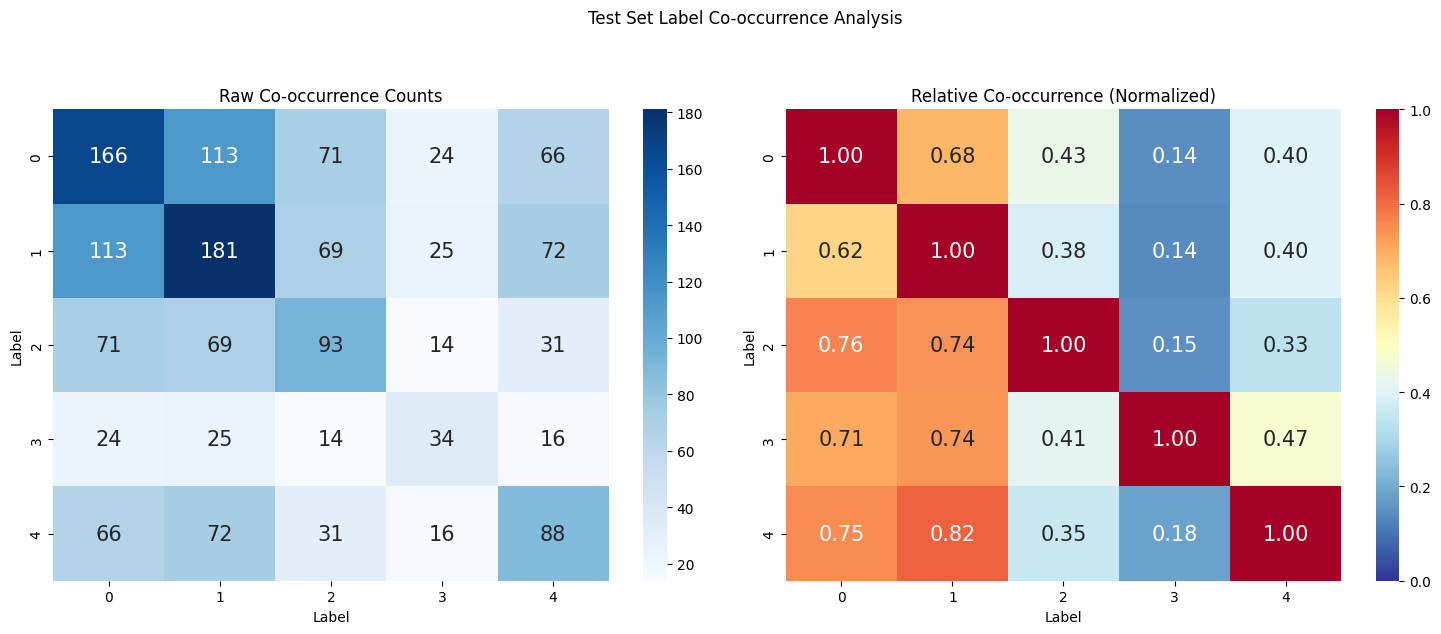

In [45]:
plot_label_cooccurrence(
  y_test, "Test Set Label Co-occurrence Analysis"
)

Co-occurrence matrix kiri menampilkan jumlah kemunculan dua label secara bersamaan. Diagonal menunjukkan total kemunculan masing-masing label. Matrix kanan menampilkan co-occurrence relatif yang dinormalisasi dari 0 sampai 1. Nilai mendekati 1 berarti label sering muncul bersama, sedangkan nilai mendekati 0 berarti label jarang muncul bersama.

### Hands-on exercises

Bagian ini hanya berupa arahan latihan. Latihan yang diminta adalah membuat dataset dengan `make_multilabel_classification()`, melatih `LogisticRegression()`, membuat prediksi, mengevaluasi accuracy dan classification report, lalu membuat visualisasi seperti confusion matrix atau heatmap.

## Model evaluation metrics

Bagian ini membahas metrik evaluasi untuk logistic regression, seperti accuracy, precision, recall, F1-score, ROC curve, dan AUC. Metrik dipilih sesuai tujuan masalah klasifikasi.

### Getting ready

Contoh kembali menggunakan dataset Breast Cancer.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
  accuracy_score, classification_report,
  precision_score, recall_score,
  f1_score, roc_curve, auc
)
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=2024
)

### How to do it

Model logistic regression dilatih menggunakan solver `liblinear`, lalu dievaluasi menggunakan beberapa metrik.

In [49]:
model = LogisticRegression(solver='liblinear')

In [50]:
model.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [51]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [52]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
report = classification_report(y_test, y_pred)

In [53]:
print(f"Accuracy {accuracy:.2f}")
print(f"Precision {precision:.2f}")
print(f"Recall {recall:.2f}")
print(f"F1 Score {f1:.2f}")
print(f"ROC AUC {roc_auc:.2f}")
print("Classification Report")
print(report)

Accuracy 0.94
Precision 0.94
Recall 0.95
F1 Score 0.95
ROC AUC 0.99
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.91      0.92        67
           1       0.94      0.95      0.95       104

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



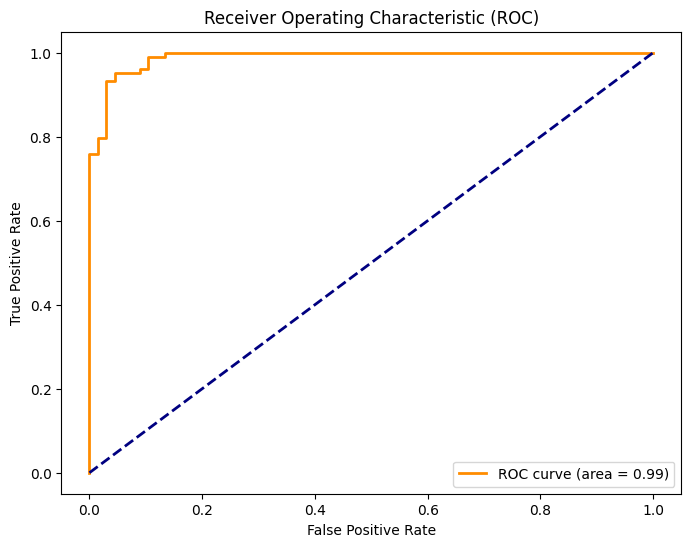

In [54]:
plt.figure(figsize=(8, 6))
plt.plot(
  fpr, tpr, color='darkorange', lw=2,
  label=f'ROC curve (area = {roc_auc:.2f})'
)
plt.plot(
  [0, 1], [0, 1], color='navy',
  lw=2, linestyle='--'
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### How it works

Accuracy mengukur proporsi prediksi yang benar. Precision mengukur seberapa banyak prediksi positif yang benar-benar positif. Recall mengukur seberapa banyak data positif yang berhasil ditemukan. F1-score adalah rata-rata harmonik dari precision dan recall. ROC curve menunjukkan hubungan true positive rate dan false positive rate pada berbagai threshold. AUC merangkum kemampuan model membedakan kelas positif dan negatif.

### Visualizing model performance

ROC curve memvisualisasikan trade-off antara true positive rate dan false positive rate. Nilai AUC yang lebih tinggi menunjukkan performa model yang lebih baik.

### There's more

Pemilihan metrik evaluasi bergantung pada tujuan klasifikasi. Jika false positive mahal, precision dapat lebih penting. Jika tujuan utama adalah menangkap sebanyak mungkin kasus positif, recall dapat lebih penting.

### Hands-on exercises

Bagian ini hanya berupa arahan latihan. Latihan yang diminta adalah menggunakan dataset Breast Cancer, melatih `LogisticRegression()`, memakai `predict()` dan `predict_proba()`, menghitung accuracy, precision, recall, F1-score, ROC AUC, lalu membuat ROC curve.

## Practical exercises with advanced logistic regression

Bagian akhir materi hanya berisi arahan latihan, sehingga tidak dibuat sebagai kode.

### Exercise 1: Building a regularized logistic regression model

Langkah latihan:

1. Load libraries.
2. Load dataset.
3. Split data.
4. Buat dan latih Lasso regularized logistic regression.
5. Buat prediksi dengan model Lasso.
6. Evaluasi performa model Lasso.

### Exercise 2: Evaluating multiclass logistic regression

Langkah latihan:

1. Load libraries.
2. Load dataset.
3. Split data.
4. Buat dan latih multinomial logistic regression.
5. Buat prediksi dengan model multinomial.
6. Evaluasi performa model multinomial.

### Exercise 3: Visualizing logistic regression results

Langkah latihan:

1. Load libraries untuk visualisasi dan pembuatan dataset.
2. Buat dataset sintetis untuk binary classification.
3. Split data.
4. Buat dan latih logistic regression.
5. Buat mesh grid untuk decision boundary.
6. Prediksi probabilitas kelas pada grid.
7. Plot decision boundary.